# Electrification in Sub-Saharan Africa (2000-2022)

## 1. Context

This project analyzes the evolution of electricity access 
in Sub-Saharan Africa over a 22-year period (2000-2022).
Using World Bank open data, we examine 15 countries to 
understand the pace of electrification, identify the best 
and worst performers, and assess whether inequalities 
between countries are narrowing or widening.

**Research questions :**
- Which countries have progressed the most ?
- Are electricity access inequalities decreasing over time ?
- Do countries in the same region share similar trajectories ? 


## 2. Dataset

| Attribute | Value |
|-----------|-------|
| Source | World Bank Open Data |
| Indicator | EG.ELC.ACCS.ZS |
| Period | 2000 – 2022 |
| Countries | 15 Sub-Saharan African countries |
| Observations | 345 rows after cleaning |

**Countries included :**
Cameroon, Nigeria, Kenya, Ethiopia, Ghana, Senegal, Mali,
Niger, Chad, Burkina Faso, Tanzania, Uganda, Rwanda,
Mozambique, Angola.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import sqlite3

## 2. Data Loading and Cleaning

In this section, we load the raw World Bank dataset and prepare 
it for analysis. The raw file requires several cleaning steps :

- **Format** : The World Bank CSV has 4 header rows to skip
- **Structure** : Data is in wide format (one column per year) 
  and needs to be reshaped to long format
- **Types** : The electricity access column is stored as string 
  and must be converted to float
- **Missing values** : Some country/year combinations have no data

After cleaning, each row represents one country for one year,
with a single electricity access value.

In [2]:
# Data loading
df_raw= pd.read_csv("API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_127016\API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_127016.csv",skiprows=4)

# filtered the useful columns
year=[str(a) for a in range(2000,2023)]
colonnes=['Country Name','Country Code']+year
df_clean=df_raw[colonnes].copy()

# rename columns
df_clean=df_clean.rename(columns={"Country Name": "pays","Country Code": "code"})

# filtered african countries

pays_afrique = ["Cameroon", "Nigeria", "Kenya", "Ethiopia", "Ghana",
                "Senegal", "Mali", "Niger", "Chad", "Burkina Faso",
                "Tanzania", "Uganda", "Rwanda", "Mozambique", "Angola"]

df_afrique=df_clean[df_clean["pays"].isin(pays_afrique)].copy()

# Convert into a long format
df_afrique_clean=df_afrique.melt(
    id_vars=["pays", "code"],
    var_name="annee",
    value_name="acces_electricite"
)

df_afrique_clean["annee"]=df_afrique_clean["annee"].astype(int)
df_afrique_clean["acces_electricite"]=pd.to_numeric(df_afrique_clean['acces_electricite'],errors="coerce")


print(df_afrique_clean.shape)
print(df_afrique_clean.head(10))
print(df_afrique_clean.isnull().sum())

(345, 4)
           pays code  annee  acces_electricite
0        Angola  AGO   2000               24.2
1  Burkina Faso  BFA   2000                9.1
2      Cameroon  CMR   2000               41.0
3      Ethiopia  ETH   2000               12.7
4         Ghana  GHA   2000               43.7
5         Kenya  KEN   2000               15.2
6          Mali  MLI   2000                9.6
7    Mozambique  MOZ   2000                6.1
8         Niger  NER   2000                6.5
9       Nigeria  NGA   2000               43.2
pays                 0
code                 0
annee                0
acces_electricite    0
dtype: int64


**Cleaning Summary :**
- The raw dataset contains 345 observations across 15 African countries
- Variables retained for analysis : country name, country code, 
  year, and electricity access level (%)
- The dataset covers 23 years (2000–2022) for all 15 countries
- No missing values remain after cleaning

## 3. Exploratory Data Analysis

In this section, we analyze the distribution and evolution 
of electricity access across our 15 countries. We examine 
the overall statistical properties of the data, track 
progress over time, and compare countries to identify 
the best and worst performers over the 2000–2022 period.

### 3.1 Descriptive Statistics

In [6]:
# Print the statistics about acces_electricite
print(df_afrique_clean['acces_electricite'].describe())

print("----------------------")

# compute the mean, median , standard deviation and IQR
print(f" Mean:{df_afrique_clean['acces_electricite'].mean():.1f}%")
print(f" Median : {df_afrique_clean['acces_electricite'].median():.1f}% ")
print(f"Standard_deviation: {df_afrique_clean['acces_electricite'].std():.1f}%")

print(f"IQR : {df_afrique_clean['acces_electricite'].quantile(0.75)- df_afrique_clean['acces_electricite'].quantile(0.25):.1f}%")

# Outliers detection
inf= df_afrique_clean['acces_electricite'].quantile(0.25)-1.5*(df_afrique_clean['acces_electricite'].quantile(0.75)- df_afrique_clean['acces_electricite'].quantile(0.25))
sup= df_afrique_clean['acces_electricite'].quantile(0.75)+1.5*(df_afrique_clean['acces_electricite'].quantile(0.75)- df_afrique_clean['acces_electricite'].quantile(0.25))

Outliers=df_afrique_clean[(df_afrique_clean['acces_electricite']<inf) | (df_afrique_clean['acces_electricite']>sup)]

print(f"Bornes    : [{inf:.1f}%, {sup:.1f}%]")
print(f"Outliers  : {len(Outliers)} valeurs")


# print the statistics per country

stat_per_country= df_afrique_clean.groupby('pays')['acces_electricite'].agg(['mean','std','min','max']).round(1)
print("----------------------------------")

stat_per_country_ordered= stat_per_country.sort_values('mean',ascending=False).copy()



# print the 3 most advanced and the 3 most in delay
print("--------------------------------")
print(stat_per_country_ordered.head(3))

print("--------------------------------")
print(stat_per_country_ordered.tail(3))

count    345.000000
mean      31.797971
std       20.543798
min        3.100000
25%       13.600000
50%       27.200000
75%       48.100000
max       86.300000
Name: acces_electricite, dtype: float64
----------------------
 Mean:31.8%
 Median : 27.2% 
Standard_deviation: 20.5%
IQR : 34.5%
Bornes    : [-38.1%, 99.8%]
Outliers  : 0 valeurs
----------------------------------
--------------------------------
          mean   std   min   max
pays                            
Ghana     65.0  15.2  41.3  86.3
Cameroon  54.4   7.9  41.0  71.0
Senegal   54.4  10.8  36.8  70.4
--------------------------------
              mean  std  min   max
pays                              
Burkina Faso  14.2  3.3  9.1  19.5
Niger         13.6  4.1  6.5  19.5
Chad           7.2  2.8  3.1  11.7


#### Analysis

The average electricity access over the period (2000–2022) 
is 31.8%, but this figure is pulled upward by the best 
performers Ghana (65%), Cameroon and Senegal (54%). 
The median (27.2%) is a more accurate representation of 
the typical African country in our dataset.

The gap between mean and median reveals a right-skewed 
distribution most countries cluster below the average, 
while a few high performers shift the mean upward.

The IQR of 34.5 points highlights strong heterogeneity 
even among "average" countries,the middle 50% of 
observations span from 13.6% to 48.1%.

The top performers over the period are Ghana (65.0%), 
Cameroon (54.4%) and Senegal (54.4%), while the weakest 
are Burkina Faso (14.2%), Niger (13.6%) and Chad (7.2%) 
all three with an average below 15%.

### 3.2 Distribution

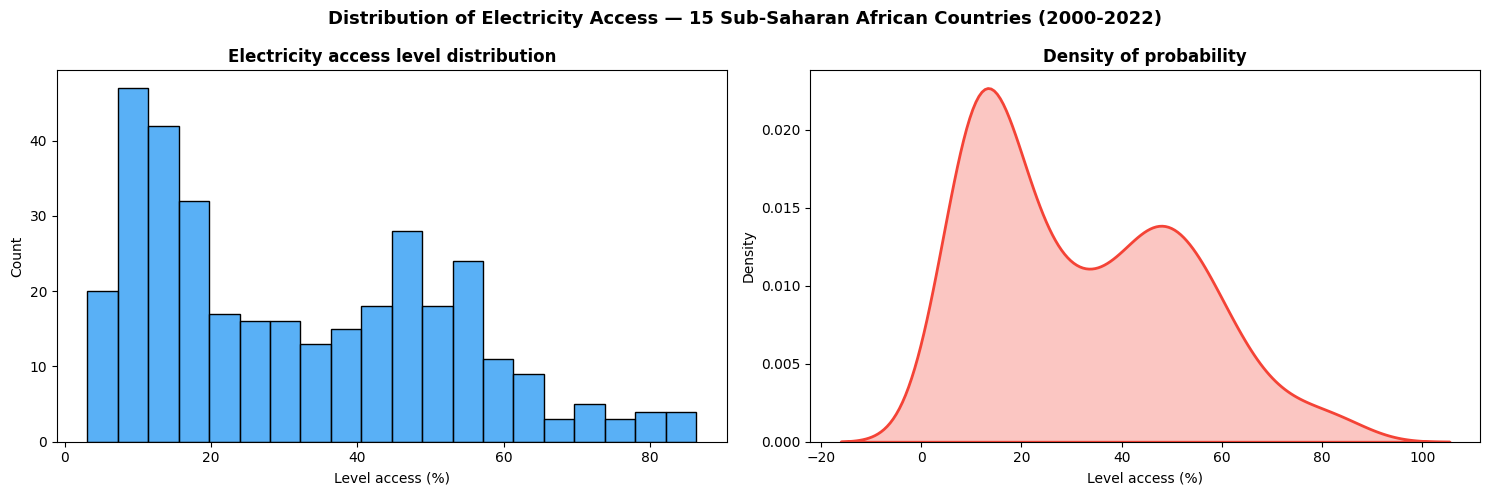

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme
sns.histplot(
    data=df_afrique_clean,
    x="acces_electricite",
    bins=20,
    color="#2196F3",
    ax=axes[0]
)
axes[0].set_title("Electricity access level distribution",
                  fontweight="bold")
axes[0].set_xlabel("Level access (%)")

# KDE — Kernel Density Estimate
sns.kdeplot(
    data=df_afrique_clean,
    x="acces_electricite",
    color="#F44336",
    linewidth=2,
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title("Density of probability", fontweight="bold")
axes[1].set_xlabel("Level access (%)")

plt.suptitle("Distribution of Electricity Access — 15 Sub-Saharan African Countries (2000-2022)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
from scipy import stats

access=df_afrique_clean['acces_electricite']

stat,p_value= stats.shapiro(access.sample(50, random_state=42))
print(f" the p_value is : {p_value}")

 the p_value is : 0.0026785636242815073


#### Analysis

The histogram and probability density plot confirm a right-skewed 
distribution of electricity access, consistent with the descriptive 
statistics from the previous section.

The Shapiro-Wilk normality test further supports this observation. 
With a p-value of 0.003 (< 0.05), we reject the null hypothesis 
that the data follows a normal distribution. This result has an 
important practical implication : non-parametric tests such as 
Mann-Whitney should be preferred over t-tests when comparing 
groups in subsequent analyses.

### 3.3 Temporal evolution

In [ ]:
Mean_africa = df_afrique_clean.groupby('annee')['acces_electricite'].mean()